In [1]:
from epyt import epanet
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Criando cluster

In [2]:
import openpyxl
from pyproj import Transformer

# Defina o transformador
transformer = Transformer.from_crs(
    "EPSG:31983",  # UTM zona 22S SIRGAS2000
    "EPSG:4674",   # SIRGAS2000 geográfico
    always_xy=True
)

# Abre a planilha
wb = openpyxl.load_workbook(r'Tabelas para calibração\Projeto Inacio\Tabela Xe Y .xlsx')
ws = wb.active

# colocar cabeçalhos nas colunas G e H
ws.cell(row=1, column=4).value = "Longitude"
ws.cell(row=1, column=5).value = "Latitude"

# Vamos percorrer a partir da linha 2
for row in ws.iter_rows(min_row=2, min_col=2, max_col=3):
    e_cell, n_cell = row
    try:
        e = float(str(e_cell.value).replace(",", "."))
        n = float(str(n_cell.value).replace(",", "."))
        lon, lat = transformer.transform(e, n)
        ws.cell(row=e_cell.row, column=4).value = lon
        ws.cell(row=e_cell.row, column=5).value = lat
    except Exception as e:
        ws.cell(row=e_cell.row, column=4).value = "erro"
        ws.cell(row=e_cell.row, column=5).value = "erro"

# salva no mesmo arquivo
wb.save(r'Tabelas para calibração\Projeto Inacio\Tabela Xe Y .xlsx')



In [13]:
#Arquivo original que gerou o arquivo Epanet
rede = pd.read_excel("Tabelas para calibração\Rede completa.xlsx")
rede

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\filipe_silva\AppData\Local\Temp\ipykernel_32408\2797339172.py:2: SyntaxWarning: invalid escape sequence '\R'
  rede = pd.read_excel("Tabelas para calibração\Rede completa.xlsx")


,Unnamed: 0.1,ID,Unnamed: 0,Shape *,creationda,DIAMETRO,MATERIAL,rugosidade,dataimplan,EXTENSAO,...,X_FIM,Y_FIM,UDA,Idade (anos),Diametro_f,Idade,Rugosidade1,CHW,NODENUM_INICIAL,NODENUM_FINAL
0,0,0,0,Polyline ZM,2025-01-15,60,PVC,0.0,NaT,24.736935,...,170041.6951,8.227777e+06,UDA.GAM.003,0,100,0,130,140.0,3585,2251
1,1,1,1,Polyline ZM,2023-03-13,63,PEAD,140.0,2022-10-03,6.339629,...,172520.7919,8.224332e+06,UDA.GAM.002,2,100,0,130,140.0,3168,3169
2,2,2,2,Polyline ZM,2023-03-13,63,PEAD,140.0,2022-10-03,210.851609,...,172526.0889,8.224328e+06,UDA.GAM.002,2,100,0,130,140.0,3167,3168
3,3,3,3,Polyline ZM,2023-03-13,63,PEAD,140.0,2022-10-03,6.137854,...,172637.1042,8.224508e+06,UDA.GAM.002,2,100,0,130,140.0,3166,3167
4,4,4,4,Polyline ZM,2023-03-13,63,PEAD,140.0,2022-10-03,1.167945,...,172479.0982,8.224357e+06,UDA.GAM.002,2,100,0,130,140.0,3165,1398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3909,3909,3909,3909,Polyline ZM,2015-02-27,300,CA,125.0,1900-01-01,33.682039,...,171758.0680,8.227258e+06,UDA.GAM.003,125,300,125,58,125.0,2590,2591
3910,3910,3910,3910,Polyline ZM,2015-02-27,300,CA,125.0,1900-01-01,30.009576,...,171728.4397,8.227242e+06,UDA.GAM.003,125,300,125,58,125.0,2589,2590
3911,3911,3911,3911,Polyline ZM,2015-02-27,300,CA,125.0,1900-01-01,21.956430,...,171701.9520,8.227228e+06,UDA.GAM.003,125,300,125,58,125.0,2588,2589
3912,3912,3912,3912,Polyline ZM,2021-06-18,85,PVC,132.5,1900-01-01,4.717077,...,173154.0222,8.225228e+06,UDA.GAM.004,125,100,125,50,132.5,2934,2935


In [14]:
rede['MATERIAL2'] = rede['MATERIAL']
rede['UDA.C'] = rede['UDA']

In [15]:
le = LabelEncoder()
rede['MATERIAL_encoded'] = le.fit_transform(rede['MATERIAL'])
rede['UDA_encoded'] = le.fit_transform(rede['UDA'])

# Supondo que df_rede seja seu dataframe


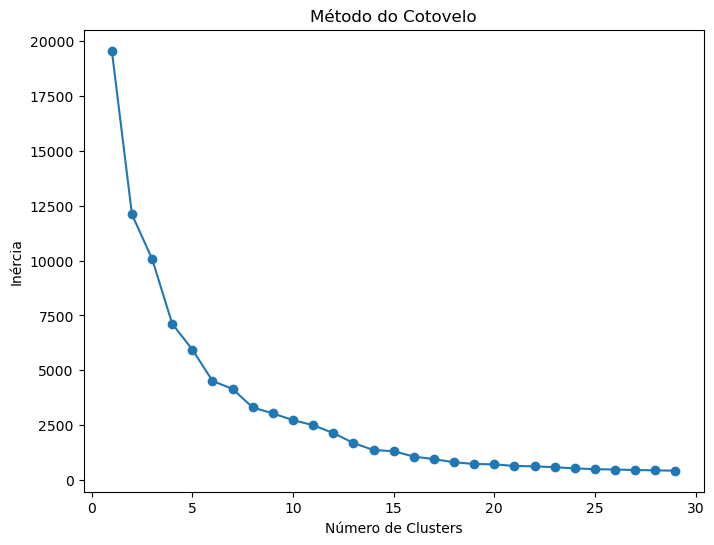

In [16]:
# Selecionando as colunas para clustering
X = rede[['DIAMETRO', 'MATERIAL_encoded', 'CHW', 'Idade (anos)', 'UDA_encoded']]

# Método do Cotovelo
# Normalizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
range_n_clusters = range(1, 30)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.show()

In [17]:
# Método da Silhueta
silhouette_scores = []
for n_clusters in range_n_clusters[1:]:  # Começar de 2 clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

print("\nMétodo da Silhueta - Coeficiente de Silhueta:")
for n_clusters, score in zip(range_n_clusters[1:], silhouette_scores):
    print(f"Número de Clusters: {n_clusters}, Coeficiente de Silhueta: {score}")


Método da Silhueta - Coeficiente de Silhueta:
Número de Clusters: 2, Coeficiente de Silhueta: 0.4733003907802138
Número de Clusters: 3, Coeficiente de Silhueta: 0.3976969011659492
Número de Clusters: 4, Coeficiente de Silhueta: 0.4570966200649006
Número de Clusters: 5, Coeficiente de Silhueta: 0.521153430219858
Número de Clusters: 6, Coeficiente de Silhueta: 0.5792637201469809
Número de Clusters: 7, Coeficiente de Silhueta: 0.6031085137962771
Número de Clusters: 8, Coeficiente de Silhueta: 0.5863250124901739
Número de Clusters: 9, Coeficiente de Silhueta: 0.6025390088953617
Número de Clusters: 10, Coeficiente de Silhueta: 0.6114206051914077
Número de Clusters: 11, Coeficiente de Silhueta: 0.6184190294888311
Número de Clusters: 12, Coeficiente de Silhueta: 0.6556511133720913
Número de Clusters: 13, Coeficiente de Silhueta: 0.6784947650295895
Número de Clusters: 14, Coeficiente de Silhueta: 0.6945909328788801
Número de Clusters: 15, Coeficiente de Silhueta: 0.696610385491593
Número de C

In [18]:
# Método da Soma das Distâncias Intra-cluster (WSS)
sum_of_squares = []
for n_clusters in range_n_clusters[1:]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled)
    sum_of_squares.append(np.sum((X_scaled - kmeans.cluster_centers_[kmeans.labels_])**2))

print("\nMétodo da Soma das Distâncias Intra-cluster (WSS):")
for n_clusters, sum_sq in zip(range_n_clusters[1:], sum_of_squares):
    print(f"Número de Clusters: {n_clusters}, Soma das Distâncias Intra-cluster: {sum_sq}")


Método da Soma das Distâncias Intra-cluster (WSS):
Número de Clusters: 2, Soma das Distâncias Intra-cluster: 12103.95857473496
Número de Clusters: 3, Soma das Distâncias Intra-cluster: 10078.630627292865
Número de Clusters: 4, Soma das Distâncias Intra-cluster: 7118.979925807711
Número de Clusters: 5, Soma das Distâncias Intra-cluster: 5942.810663704788
Número de Clusters: 6, Soma das Distâncias Intra-cluster: 4513.981310542673
Número de Clusters: 7, Soma das Distâncias Intra-cluster: 4144.743205769808
Número de Clusters: 8, Soma das Distâncias Intra-cluster: 3302.5980517380813
Número de Clusters: 9, Soma das Distâncias Intra-cluster: 3030.616599747982
Número de Clusters: 10, Soma das Distâncias Intra-cluster: 2724.4384496724256
Número de Clusters: 11, Soma das Distâncias Intra-cluster: 2494.423781276784
Número de Clusters: 12, Soma das Distâncias Intra-cluster: 2135.953384942593
Número de Clusters: 13, Soma das Distâncias Intra-cluster: 1684.1537129886476
Número de Clusters: 14, Soma

In [19]:
Colunas = ['DIAMETRO', 'MATERIAL_encoded', 'CHW', 'Idade (anos)', 'UDA_encoded']

# Normalizar os dados para evitar que colunas com escalas maiores dominem o cluster
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(rede[Colunas])

# Definir o número de clusters (ex: 3)
n_clusters = 20

# Aplicar K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
rede['cluster'] = kmeans.fit_predict(dados_normalizados)



In [20]:
# Imprimir a quantidade de itens em cada cluster
quantidade_por_cluster = rede['cluster'].value_counts()
print(quantidade_por_cluster)

cluster
15    1053
5      509
0      386
8      333
11     296
4      180
6      151
19     138
1      137
7      117
12      98
16      93
3       91
9       85
10      60
18      57
17      57
2       40
13      23
14      10
Name: count, dtype: int64


In [32]:
filtro = rede[rede['cluster']==0]
# rede['Idade (anos)'].value_counts()
ftr = filtro[['DIAMETRO', 'MATERIAL', 'CHW', 'Idade (anos)', 'UDA']]
ftr['Idade (anos)'].value_counts()

Idade (anos)
40    259
41    108
54      8
18      6
36      3
52      2
Name: count, dtype: int64